In [ ]:
%pip install scikit-learn

In [ ]:
import pandas as pd
import os

In [2]:
df = pd.read_csv("../dataset/Monday-WorkingHours.pcap_ISCX.csv")
df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,4,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,1,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,1,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,1,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,192.168.10.14-8.253.185.121-49486-80-6,8.253.185.121,80,192.168.10.14,49486,6,03/07/2017 08:56:22,3,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [4]:
print(df.shape)

(529918, 85)


In [5]:
df.columns

Index(['Flow ID', ' Source IP', ' Source Port', ' Destination IP',
       ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Pa

In [7]:
df[' Label'].value_counts()

 Label
BENIGN    529918
Name: count, dtype: int64

These labels will be used later for

#Binary classifiaction (Attack vs Normal)

#Multiclass classification (attack type)

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1) Clean names and target
df.columns = df.columns.str.strip()
df["target"] = (df["Label"] != "BENIGN").astype(np.int8)

# 2) Drop very high-cardinality / identifier columns if present
drop_cols = ["Label", "target", "Flow ID", "Source IP", "Destination IP", "Timestamp"]
drop_cols = [c for c in drop_cols if c in df.columns]
X = df.drop(columns=drop_cols)
y = df["target"]

# 3) Keep only numeric columns first (fast + memory-safe baseline)
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.float32)

# Optional: sample for first successful run
sample_n = min(200000, len(X))
if len(X) > sample_n:
    idx = np.random.RandomState(42).choice(len(X), size=sample_n, replace=False)
    X = X.iloc[idx]
    y = y.iloc[idx]

print("X shape:", X.shape)
print("X memory (GB):", round(X.memory_usage(deep=True).sum() / 1e9, 3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=80,      # start smaller
    random_state=42,
    n_jobs=1,             # avoid parallel memory blow-up
    class_weight="balanced"
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Safe probability extraction even if only one class is present
proba = model.predict_proba(X_test)
if proba.shape[1] == 1:
    only_class = model.classes_[0]
    y_prob = np.ones(len(X_test), dtype=np.float32) if only_class == 1 else np.zeros(len(X_test), dtype=np.float32)
else:
    pos_idx = np.where(model.classes_ == 1)[0][0]
    y_prob = proba[:, pos_idx]

X shape: (200000, 80)
X memory (GB): 0.066


In [7]:
import joblib
joblib.dump(model, "../dataset/rf_binary_baseline.joblib")
print("saved")

saved


In [8]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Positive rate in y:", y.mean())

Train shape: (160000, 80)
Test shape: (40000, 80)
Positive rate in y: 0.0


In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

Accuracy: 1.0

Confusion Matrix:
[[40000]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     40000

    accuracy                         1.0000     40000
   macro avg     1.0000    1.0000    1.0000     40000
weighted avg     1.0000    1.0000    1.0000     40000



/Users/mrnobody/Documents/project4_AI&ML/IDS_Project/my_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


## Pipeline Status
- Data loaded and cleaned
- Binary target created (`BENIGN=0`, attack=`1`)
- Features prepared and model trained
- Accuracy and classification report generated

Matplotlib is building the font cache; this may take a moment.


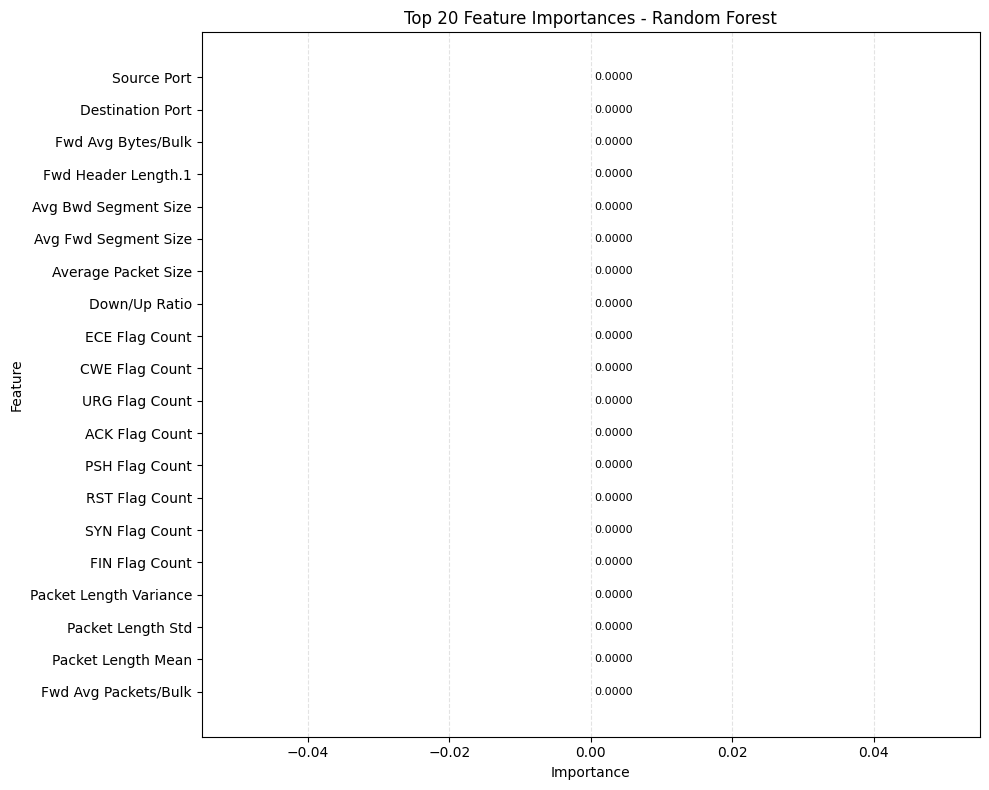

Saved plot: ../dataset/feature_importance_top20.png

Top 10 Features:
                 feature  importance
19           Source Port         0.0
18      Destination Port         0.0
17    Fwd Avg Bytes/Bulk         0.0
16   Fwd Header Length.1         0.0
15  Avg Bwd Segment Size         0.0
14  Avg Fwd Segment Size         0.0
13   Average Packet Size         0.0
12         Down/Up Ratio         0.0
11        ECE Flag Count         0.0
10        CWE Flag Count         0.0


In [ ]:
# Top feature importance chart for Random Forest
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_names = X_train.columns

fi = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
    .iloc[::-1]
    .reset_index(drop=True)
 )

plt.figure(figsize=(10, 8))
bars = plt.barh(fi["feature"], fi["importance"], color="#1f77b4")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - Random Forest")
plt.grid(axis="x", linestyle="--", alpha=0.35)

# Add readable labels on bars
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.0005, bar.get_y() + bar.get_height() / 2, f"{w:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("../dataset/feature_importance_top20.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot: ../dataset/feature_importance_top20.png")
print("\nTop 10 Features:")
print(fi.iloc[::-1].head(10).sort_values("importance", ascending=False))

In [5]:
# Quick check: class balance in current training data
print(y.value_counts(dropna=False))
print("y unique:", sorted(y.unique().tolist()))

target
0    200000
Name: count, dtype: int64
y unique: [0]


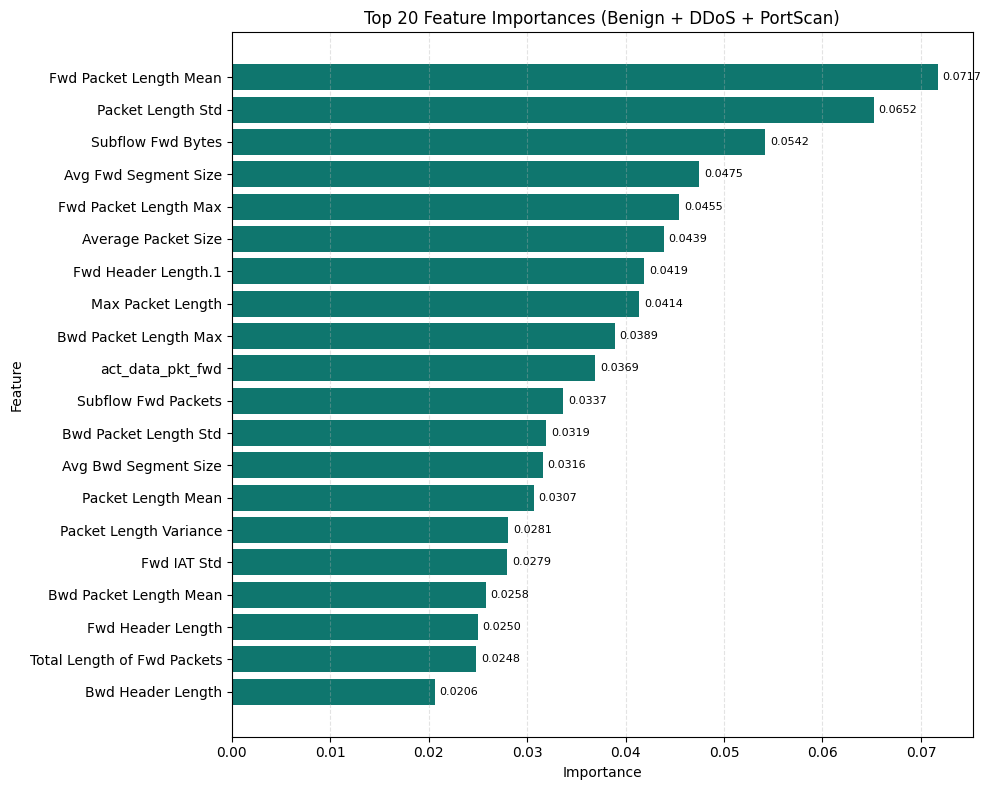

Class balance:
target
0    209230
1     30770
Name: count, dtype: int64

Saved plot: ../dataset/feature_importance_presentation.png

Top 10 Features:
                   feature  importance
19  Fwd Packet Length Mean    0.071692
18       Packet Length Std    0.065203
17       Subflow Fwd Bytes    0.054154
16    Avg Fwd Segment Size    0.047494
15   Fwd Packet Length Max    0.045450
14     Average Packet Size    0.043853
13     Fwd Header Length.1    0.041918
12       Max Packet Length    0.041377
11   Bwd Packet Length Max    0.038905
10        act_data_pkt_fwd    0.036905


In [6]:
# Presentation-ready feature importance using mixed benign + attack data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

benign_path = "../dataset/Monday-WorkingHours.pcap_ISCX.csv"
attack_paths = [
    "../dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "../dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
]

# Keep rows moderate for fast notebook execution
benign_df = pd.read_csv(benign_path, nrows=120000)
attack_df_list = [pd.read_csv(p, nrows=60000) for p in attack_paths]
df_mix = pd.concat([benign_df] + attack_df_list, ignore_index=True)

df_mix.columns = df_mix.columns.str.strip()
df_mix["target"] = (df_mix["Label"] != "BENIGN").astype(np.int8)

drop_cols = ["Label", "target", "Flow ID", "Source IP", "Destination IP", "Timestamp"]
drop_cols = [c for c in drop_cols if c in df_mix.columns]

X_mix = df_mix.drop(columns=drop_cols)
X_mix = X_mix.select_dtypes(include=[np.number])
X_mix = X_mix.replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.float32)
y_mix = df_mix["target"]

Xtr, Xte, ytr, yte = train_test_split(
    X_mix, y_mix, test_size=0.2, random_state=42, stratify=y_mix
)

rf_mix = RandomForestClassifier(
    n_estimators=120, random_state=42, n_jobs=1, class_weight="balanced"
)
rf_mix.fit(Xtr, ytr)

fi_mix = (
    pd.DataFrame({"feature": X_mix.columns, "importance": rf_mix.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(20)
    .iloc[::-1]
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 8))
bars = plt.barh(fi_mix["feature"], fi_mix["importance"], color="#0f766e")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances (Benign + DDoS + PortScan)")
plt.grid(axis="x", linestyle="--", alpha=0.35)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.0005, bar.get_y() + bar.get_height() / 2, f"{w:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("../dataset/feature_importance_presentation.png", dpi=300, bbox_inches="tight")
plt.show()

print("Class balance:")
print(y_mix.value_counts())
print("\nSaved plot: ../dataset/feature_importance_presentation.png")
print("\nTop 10 Features:")
print(fi_mix.iloc[::-1].head(10).sort_values("importance", ascending=False))

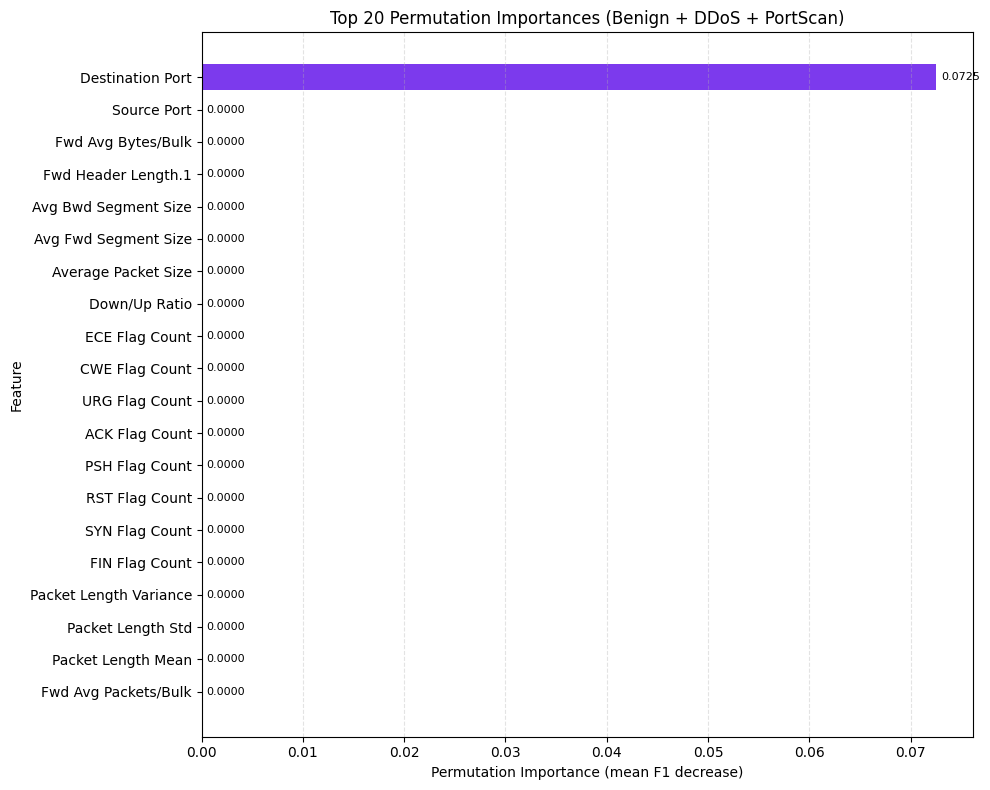

Saved plot: ../dataset/permutation_importance_presentation.png

Performance Summary (mixed test set):
   Accuracy  Precision  Recall      F1  ROC-AUC
0    0.9998        1.0  0.9987  0.9993      1.0


In [7]:
# Permutation importance + metrics summary for presentation
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Use a manageable subset for fast, stable permutation importance
perm_n = min(20000, len(Xte))
X_perm = Xte.iloc[:perm_n]
y_perm = yte.iloc[:perm_n]

perm = permutation_importance(
    rf_mix,
    X_perm,
    y_perm,
    n_repeats=3,
    random_state=42,
    n_jobs=1,
    scoring="f1"
 )

perm_df = (
    pd.DataFrame({
        "feature": X_perm.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .head(20)
    .iloc[::-1]
    .reset_index(drop=True)
 )

plt.figure(figsize=(10, 8))
bars = plt.barh(perm_df["feature"], perm_df["importance_mean"], color="#7c3aed")
plt.xlabel("Permutation Importance (mean F1 decrease)")
plt.ylabel("Feature")
plt.title("Top 20 Permutation Importances (Benign + DDoS + PortScan)")
plt.grid(axis="x", linestyle="--", alpha=0.35)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.0005, bar.get_y() + bar.get_height() / 2, f"{w:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("../dataset/permutation_importance_presentation.png", dpi=300, bbox_inches="tight")
plt.show()

# Metrics summary table on mixed test set
y_pred_mix = rf_mix.predict(Xte)
proba_mix = rf_mix.predict_proba(Xte)
pos_idx = int(np.where(rf_mix.classes_ == 1)[0][0])
y_prob_mix = proba_mix[:, pos_idx]

metrics_df = pd.DataFrame([
    {
        "Accuracy": accuracy_score(yte, y_pred_mix),
        "Precision": precision_score(yte, y_pred_mix, zero_division=0),
        "Recall": recall_score(yte, y_pred_mix, zero_division=0),
        "F1": f1_score(yte, y_pred_mix, zero_division=0),
        "ROC-AUC": roc_auc_score(yte, y_prob_mix),
    }
]).round(4)

print("Saved plot: ../dataset/permutation_importance_presentation.png")
print("\nPerformance Summary (mixed test set):")
print(metrics_df)

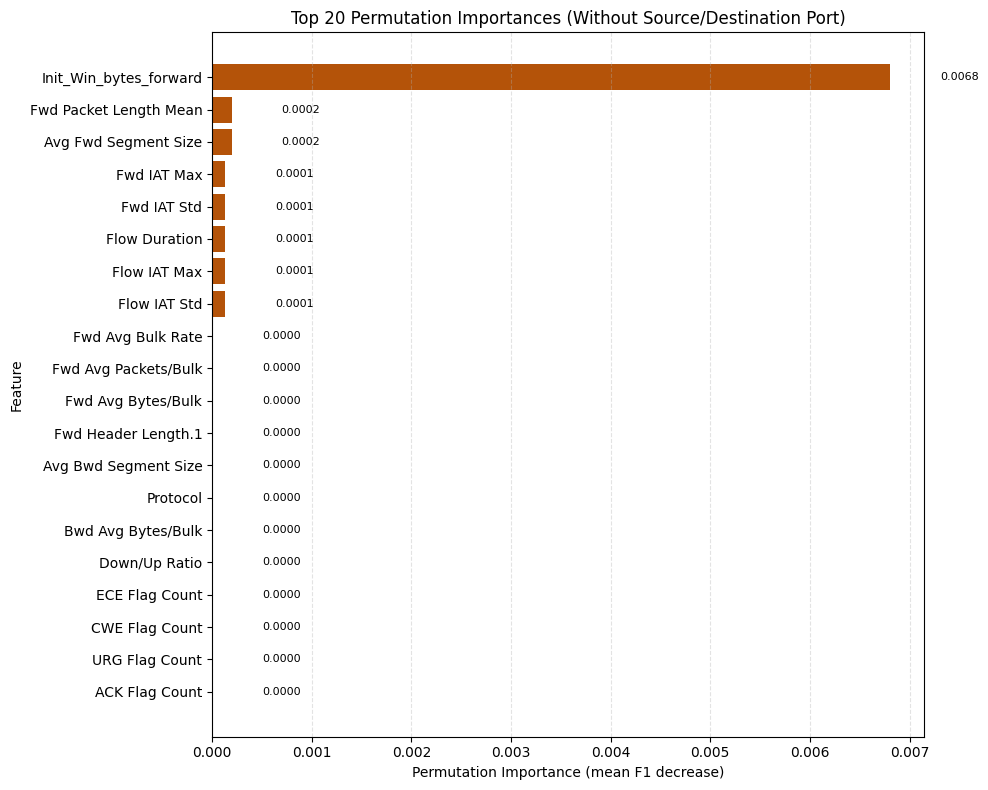

Dropped columns: ['Source Port', 'Destination Port']
Saved plot: ../dataset/permutation_importance_no_ports.png
Saved table: ../dataset/metrics_with_without_ports.csv

Metrics comparison:
         Setting  Accuracy  Precision  Recall      F1  ROC-AUC
0     With Ports    0.9998     1.0000  0.9987  0.9993      1.0
1  Without Ports    0.9998     0.9998  0.9982  0.9990      1.0


In [8]:
# Leakage check: retrain without port features and compare
leak_cols = [c for c in ["Source Port", "Destination Port"] if c in X_mix.columns]
X_mix_nop = X_mix.drop(columns=leak_cols).copy()

Xtr_nop, Xte_nop, ytr_nop, yte_nop = train_test_split(
    X_mix_nop, y_mix, test_size=0.2, random_state=42, stratify=y_mix
)

rf_mix_nop = RandomForestClassifier(
    n_estimators=120, random_state=42, n_jobs=1, class_weight="balanced"
)
rf_mix_nop.fit(Xtr_nop, ytr_nop)

y_pred_nop = rf_mix_nop.predict(Xte_nop)
proba_nop = rf_mix_nop.predict_proba(Xte_nop)
pos_idx_nop = int(np.where(rf_mix_nop.classes_ == 1)[0][0])
y_prob_nop = proba_nop[:, pos_idx_nop]

metrics_compare = pd.DataFrame([
    {
        "Setting": "With Ports",
        "Accuracy": accuracy_score(yte, y_pred_mix),
        "Precision": precision_score(yte, y_pred_mix, zero_division=0),
        "Recall": recall_score(yte, y_pred_mix, zero_division=0),
        "F1": f1_score(yte, y_pred_mix, zero_division=0),
        "ROC-AUC": roc_auc_score(yte, y_prob_mix),
    },
    {
        "Setting": "Without Ports",
        "Accuracy": accuracy_score(yte_nop, y_pred_nop),
        "Precision": precision_score(yte_nop, y_pred_nop, zero_division=0),
        "Recall": recall_score(yte_nop, y_pred_nop, zero_division=0),
        "F1": f1_score(yte_nop, y_pred_nop, zero_division=0),
        "ROC-AUC": roc_auc_score(yte_nop, y_prob_nop),
    },
]).round(4)

# Permutation importance without ports
perm_nop = permutation_importance(
    rf_mix_nop,
    Xte_nop.iloc[:min(20000, len(Xte_nop))],
    yte_nop.iloc[:min(20000, len(yte_nop))],
    n_repeats=3,
    random_state=42,
    n_jobs=1,
    scoring="f1"
)
perm_nop_df = (
    pd.DataFrame({
        "feature": Xte_nop.columns,
        "importance_mean": perm_nop.importances_mean
    })
    .sort_values("importance_mean", ascending=False)
    .head(20)
    .iloc[::-1]
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 8))
bars = plt.barh(perm_nop_df["feature"], perm_nop_df["importance_mean"], color="#b45309")
plt.xlabel("Permutation Importance (mean F1 decrease)")
plt.ylabel("Feature")
plt.title("Top 20 Permutation Importances (Without Source/Destination Port)")
plt.grid(axis="x", linestyle="--", alpha=0.35)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.0005, bar.get_y() + bar.get_height() / 2, f"{w:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("../dataset/permutation_importance_no_ports.png", dpi=300, bbox_inches="tight")
plt.show()

metrics_compare.to_csv("../dataset/metrics_with_without_ports.csv", index=False)
print("Dropped columns:", leak_cols)
print("Saved plot: ../dataset/permutation_importance_no_ports.png")
print("Saved table: ../dataset/metrics_with_without_ports.csv")
print("\nMetrics comparison:")
print(metrics_compare)

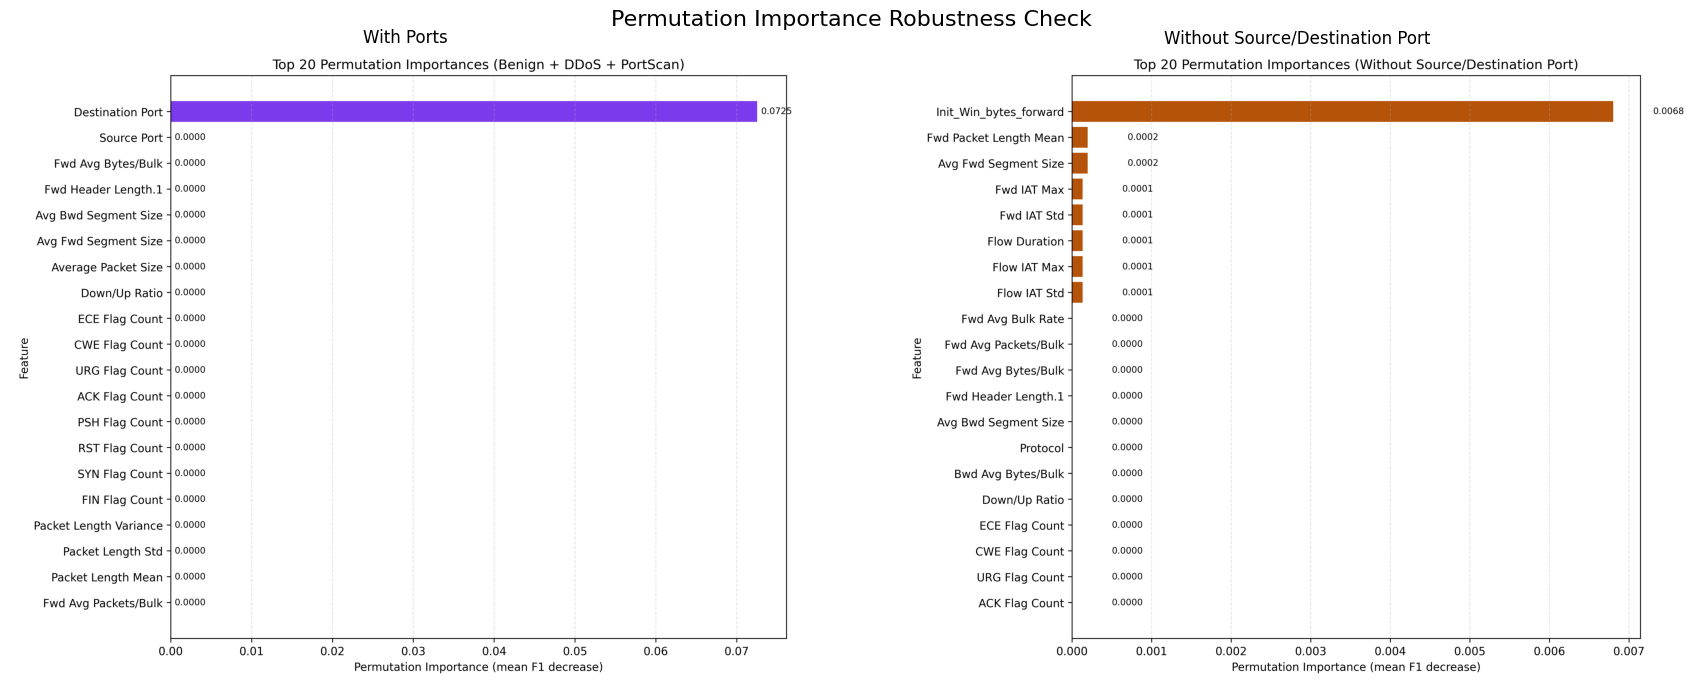

Saved comparison: ../dataset/permutation_importance_side_by_side.png


In [9]:
# Side-by-side comparison figure for slides
img_with_ports = plt.imread("../dataset/permutation_importance_presentation.png")
img_without_ports = plt.imread("../dataset/permutation_importance_no_ports.png")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(img_with_ports)
axes[0].set_title("With Ports")
axes[0].axis("off")

axes[1].imshow(img_without_ports)
axes[1].set_title("Without Source/Destination Port")
axes[1].axis("off")

fig.suptitle("Permutation Importance Robustness Check", fontsize=16)
plt.tight_layout()
plt.savefig("../dataset/permutation_importance_side_by_side.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved comparison: ../dataset/permutation_importance_side_by_side.png")